# Ejemplo 3 — PSO para entrenar una Red Neuronal sin Backpropagation

**Actividad 03 — Algoritmos de Enjambre aplicados al Aprendizaje Automático**

## Objetivo

Entrenar una red neuronal de **tres capas con parámetros entrenables** usando PSO para hallar todos sus pesos y bias **sin usar backpropagation**.

Arquitectura:

`4 entradas → 6 neuronas → 5 neuronas → 3 salidas`

Las tres capas entrenables son:

1. entrada → capa oculta 1;
2. capa oculta 1 → capa oculta 2;
3. capa oculta 2 → salida.

No se usa `MLPClassifier`, TensorFlow, Keras ni `backward()`. Solo se implementa **forward propagation** y PSO modifica directamente el vector completo de pesos y bias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

SEMILLA = 42

datos = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    datos.data, datos.target,
    test_size=0.20,
    stratify=datos.target,
    random_state=SEMILLA
)

escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_test = escalador.transform(X_test)

N_ENTRADAS = X_train.shape[1]   # 4
H1 = 6
H2 = 5
N_SALIDAS = len(np.unique(y_train))  # 3

# Número total de pesos y bias que una partícula debe representar
DIMENSION = (
    N_ENTRADAS * H1 + H1
    + H1 * H2 + H2
    + H2 * N_SALIDAS + N_SALIDAS
)

print("Arquitectura: 4 -> 6 -> 5 -> 3")
print("Parámetros totales (pesos + bias):", DIMENSION)

Arquitectura: 4 -> 6 -> 5 -> 3
Parámetros totales (pesos + bias): 83


## Representación de la partícula

Cada partícula es un vector continuo de longitud `DIMENSION`.

Ese vector contiene, en orden:

- matriz `W1` y bias `b1`;
- matriz `W2` y bias `b2`;
- matriz `W3` y bias `b3`.

La partícula, por tanto, representa **una red neuronal completa**.

In [2]:
def desempaquetar(parametros):
    i = 0

    W1 = parametros[i:i + N_ENTRADAS * H1].reshape(N_ENTRADAS, H1)
    i += N_ENTRADAS * H1

    b1 = parametros[i:i + H1]
    i += H1

    W2 = parametros[i:i + H1 * H2].reshape(H1, H2)
    i += H1 * H2

    b2 = parametros[i:i + H2]
    i += H2

    W3 = parametros[i:i + H2 * N_SALIDAS].reshape(H2, N_SALIDAS)
    i += H2 * N_SALIDAS

    b3 = parametros[i:i + N_SALIDAS]

    return W1, b1, W2, b2, W3, b3

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(parametros, X):
    W1, b1, W2, b2, W3, b3 = desempaquetar(parametros)

    a1 = np.tanh(X @ W1 + b1)
    a2 = np.tanh(a1 @ W2 + b2)
    logits = a2 @ W3 + b3

    return softmax(logits)

## Función de aptitud

Se minimiza la **entropía cruzada** calculada únicamente a partir de la salida del *forward pass*.

No se calculan gradientes.

PSO prueba diferentes vectores de pesos y bias; las partículas con menor pérdida se convierten en mejores personales y guían al enjambre.

In [3]:
def perdida_entropia_cruzada(parametros):
    probabilidades = forward(parametros, X_train)
    probs_correctas = probabilidades[
        np.arange(len(y_train)),
        y_train
    ]
    return -np.mean(np.log(probs_correctas + 1e-12))

def accuracy_red(parametros, X, y):
    pred = np.argmax(forward(parametros, X), axis=1)
    return accuracy_score(y, pred)

In [4]:
def pso_entrenar_red(
    numero_particulas=20,
    iteraciones=30,
    w=0.72,
    c1=1.49,
    c2=1.49
):
    rng = np.random.default_rng(SEMILLA)

    # Inicialización del enjambre
    posiciones = rng.uniform(
        -1.0, 1.0,
        size=(numero_particulas, DIMENSION)
    )
    velocidades = rng.uniform(
        -0.10, 0.10,
        size=(numero_particulas, DIMENSION)
    )

    perdidas = np.array([
        perdida_entropia_cruzada(p)
        for p in posiciones
    ])

    pbest_posiciones = posiciones.copy()
    pbest_perdidas = perdidas.copy()

    indice = int(np.argmin(pbest_perdidas))
    gbest_posicion = pbest_posiciones[indice].copy()
    gbest_perdida = pbest_perdidas[indice]

    historial = []

    print("INICIO PSO - ENTRENAMIENTO NN SIN BACKPROPAGATION")
    print("=" * 80)

    for it in range(1, iteraciones + 1):
        r1 = rng.random(posiciones.shape)
        r2 = rng.random(posiciones.shape)

        # Comportamiento de las partículas
        velocidades = (
            w * velocidades
            + c1 * r1 * (pbest_posiciones - posiciones)
            + c2 * r2 * (gbest_posicion - posiciones)
        )

        velocidades = np.clip(velocidades, -0.5, 0.5)
        posiciones = np.clip(posiciones + velocidades, -3.0, 3.0)

        perdidas = np.array([
            perdida_entropia_cruzada(p)
            for p in posiciones
        ])

        # Mejor personal
        mejoraron = perdidas < pbest_perdidas
        pbest_posiciones[mejoraron] = posiciones[mejoraron]
        pbest_perdidas[mejoraron] = perdidas[mejoraron]

        # Mejor global
        indice = int(np.argmin(pbest_perdidas))
        if pbest_perdidas[indice] < gbest_perdida:
            gbest_posicion = pbest_posiciones[indice].copy()
            gbest_perdida = pbest_perdidas[indice]

        acc_train = accuracy_red(gbest_posicion, X_train, y_train)

        historial.append({
            "iteracion": it,
            "mejor_perdida": gbest_perdida,
            "accuracy_train": acc_train
        })

        if it == 1 or it % 5 == 0 or it == iteraciones:
            print(
                f"Iteración {it:02d} | "
                f"Mejor pérdida: {gbest_perdida:.4f} | "
                f"Accuracy train: {acc_train:.4f}"
            )

    return gbest_posicion, gbest_perdida, pd.DataFrame(historial)

mejores_parametros_nn, mejor_perdida_nn, historial_nn = pso_entrenar_red()

INICIO PSO - ENTRENAMIENTO NN SIN BACKPROPAGATION
Iteración 01 | Mejor pérdida: 0.8200 | Accuracy train: 0.4250
Iteración 05 | Mejor pérdida: 0.3965 | Accuracy train: 0.8500
Iteración 10 | Mejor pérdida: 0.2221 | Accuracy train: 0.9250
Iteración 15 | Mejor pérdida: 0.0959 | Accuracy train: 0.9750
Iteración 20 | Mejor pérdida: 0.0688 | Accuracy train: 0.9667
Iteración 25 | Mejor pérdida: 0.0622 | Accuracy train: 0.9750
Iteración 30 | Mejor pérdida: 0.0567 | Accuracy train: 0.9750


In [5]:
# Resultado final
pred_test_nn = np.argmax(
    forward(mejores_parametros_nn, X_test),
    axis=1
)
accuracy_test_nn = accuracy_score(y_test, pred_test_nn)

print("\nRESULTADO FINAL NN SIN BACKPROPAGATION")
print("=" * 60)
print(f"Mejor pérdida de entrenamiento: {mejor_perdida_nn:.4f}")
print(f"Accuracy train: {accuracy_red(mejores_parametros_nn, X_train, y_train):.4f}")
print(f"Accuracy test: {accuracy_test_nn:.4f}")
print("Se optimizaron", DIMENSION, "pesos y bias mediante PSO.")
print("No se utilizó backpropagation.")


RESULTADO FINAL NN SIN BACKPROPAGATION
Mejor pérdida de entrenamiento: 0.0567
Accuracy train: 0.9750
Accuracy test: 1.0000
Se optimizaron 83 pesos y bias mediante PSO.
No se utilizó backpropagation.


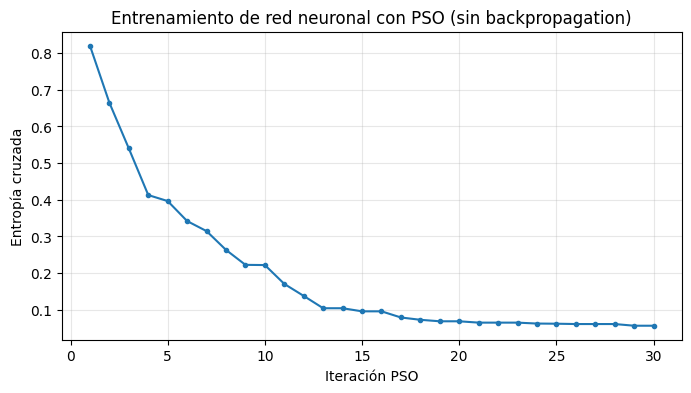

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historial_nn["iteracion"], historial_nn["mejor_perdida"], marker="o", markersize=3)
plt.xlabel("Iteración PSO")
plt.ylabel("Entropía cruzada")
plt.title("Entrenamiento de red neuronal con PSO (sin backpropagation)")
plt.grid(alpha=0.3)
plt.show()